In [1]:
import json
import matplotlib.pyplot as plt
import torch
import numpy as np
import random
import rich
import matplotlib.pyplot as plt
import pandas as pd
import sklearn

from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from rich.progress import Progress
from torchinfo import summary
from torch import nn
from torchvision import datasets, models
from torch.utils.data import Subset, ConcatDataset, DataLoader

In [2]:
# Set random seed for reproducibility
RANDOM_SEED = 0
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)

In [3]:
with open("split_indices.json", "r") as f:
    indices = json.load(f)

# Get the indices for each split
train_indices = indices["train"]
val_indices = indices["val"]
test_indices = indices["test"]

# Check if number of indices in each split is consistent
print(f"Train: {len(train_indices)}\nVal: {len(val_indices)}\nTest: {len(test_indices)}")

Train: 2284
Val: 490
Test: 490


# DATA LOADING

In [ ]:
!unzip -q Dataset.zip

In [4]:
weights = models.EfficientNet_B0_Weights.IMAGENET1K_V1
preprocess = weights.transforms() # Transformation steps for ResNet50

In [5]:
# Ignore the current train/test split. Combine into 1 unified dataset before split using indices for reproducibility
DATASET1_PATH = "/home/sagemaker-user/A3/Training"
DATASET2_PATH = "/home/sagemaker-user/A3/Testing"

# TRAIN DATASET + DATALOADER
train_dataset = Subset(ConcatDataset([datasets.ImageFolder(DATASET1_PATH, transform=preprocess),
                                      datasets.ImageFolder(DATASET2_PATH, transform=preprocess)]), 
                                      train_indices)
train_dataloader = DataLoader(dataset=train_dataset, batch_size=32, shuffle=True)

# VALIDATION DATASET + DATALOADER (SAME TRANSFORMATION AS TEST DATASET)
val_dataset = Subset(ConcatDataset([datasets.ImageFolder(DATASET1_PATH, transform=preprocess),
                                    datasets.ImageFolder(DATASET2_PATH, transform=preprocess)]), 
                                    val_indices)
val_dataloader = DataLoader(dataset=val_dataset, batch_size=16, shuffle=False)

# TEST DATASET
test_dataset = Subset(ConcatDataset([datasets.ImageFolder(DATASET1_PATH, transform=preprocess),
                                     datasets.ImageFolder(DATASET2_PATH, transform=preprocess)]), 
                                     test_indices)
test_dataloader = DataLoader(dataset=test_dataset, batch_size=16, shuffle=False)

# MODEL TRAINING

In [6]:
# DOWNLOAD + MODIFY MODEL
model = models.efficientnet_b0(weights=weights, progress=True)
model.classifier = nn.Sequential(nn.Dropout(p=0.6),
                                 nn.Linear(in_features=1280, out_features=4, bias=True))

for param in model.parameters():
    param.requires_grad = True
    
summary(model, input_size=(32, 3, 224, 224))

Layer (type:depth-idx)                                  Output Shape              Param #
EfficientNet                                            [32, 4]                   --
├─Sequential: 1-1                                       [32, 1280, 7, 7]          --
│    └─Conv2dNormActivation: 2-1                        [32, 32, 112, 112]        --
│    │    └─Conv2d: 3-1                                 [32, 32, 112, 112]        864
│    │    └─BatchNorm2d: 3-2                            [32, 32, 112, 112]        64
│    │    └─SiLU: 3-3                                   [32, 32, 112, 112]        --
│    └─Sequential: 2-2                                  [32, 16, 112, 112]        --
│    │    └─MBConv: 3-4                                 [32, 16, 112, 112]        1,448
│    └─Sequential: 2-3                                  [32, 24, 56, 56]          --
│    │    └─MBConv: 3-5                                 [32, 24, 56, 56]          6,004
│    │    └─MBConv: 3-6                              

In [7]:
# SET UP HYPERPARAMETERS
LEARNING_RATE = 0.0001
EPOCHS = 100
PATIENCE = 10
NO_IMPROVE = 0
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
WEIGHT_DECAY = 0.001
BEST_VAL_LOSS = float("inf")

if WEIGHT_DECAY == None:
    OPTIMIZER = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
else:
    OPTIMIZER = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

SCHEDULER = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer=OPTIMIZER, mode="min", factor=0.5, patience=PATIENCE/2)

# CALCULATE CLASS WEIGHTS
class_count = [0] * 4

for _, label in train_dataset:
    class_count[label] += 1

class_weights = torch.tensor(list(map(lambda x: 1 / x, class_count)), dtype=torch.float).to(DEVICE)
LOSS_FUNC = nn.CrossEntropyLoss(weight=class_weights)

In [8]:
# TRAINING LOOP
model.to(DEVICE)
train_loss_over_time = []
val_loss_over_time = []
    
with Progress() as progress:
    epoch_counter = progress.add_task(description="EPOCH", total=EPOCHS)
    batch_counter = progress.add_task(description="BATCH", total=len(train_dataloader))

    for epoch in range(EPOCHS):
        train_loss, train_correct = 0, 0
        val_loss, val_correct = 0, 0
        
        # ================================= TRAIN ===========================================
        for images, labels in train_dataloader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            model.train()
            y_logits = model(images)
            y_probs = torch.softmax(y_logits, dim=1)
            y_preds = torch.argmax(y_probs, dim=1)
            train_correct += (y_preds == labels).sum().item()
            
            loss = LOSS_FUNC(y_logits, labels)
            train_loss += loss.item()  # Accumlate loss of each batch
            OPTIMIZER.zero_grad()
            loss.backward()  # Backpropagation
            OPTIMIZER.step()

            progress.update(batch_counter, advance=1)

        train_loss = train_loss / len(train_dataloader)
        train_acc = train_correct / len(train_dataset)
        train_loss_over_time.append(train_loss) # Record loss for batch per epoch

        # ================================= VALIDATE ============================================
        model.eval()

        with torch.inference_mode():
            for images, labels in val_dataloader:
                images = images.to(DEVICE)
                labels = labels.to(DEVICE)
    
                y_logits = model(images)
                y_probs = torch.softmax(y_logits, dim=1)
                y_preds = torch.argmax(y_probs, dim=1)
                val_correct += (y_preds == labels).sum().item()
                
                loss = LOSS_FUNC(y_logits, labels)
                val_loss += loss.item()

        val_loss = val_loss / len(val_dataloader)
        val_acc = val_correct / len(val_dataset)
        val_loss_over_time.append(val_loss)
        progress.update(epoch_counter, advance=1)
        progress.reset(batch_counter)
        SCHEDULER.step(val_loss)
        print(f"TRAIN: Loss = {train_loss: .3f} Accuracy = {train_acc: .3f} | VAL: Loss = {val_loss: .3f} Accuracy = {val_acc: .3f}")
        
        # ===================== EARLY STOPPING ==================================
        if val_loss < BEST_VAL_LOSS:
            BEST_VAL_LOSS = val_loss
            NO_IMPROVE = 0
            torch.save(model.state_dict(), "best_weights.pth")
        else:
            NO_IMPROVE += 1
            if NO_IMPROVE >= PATIENCE:
                print("Early stopping triggered")
                break

Output()

TRAIN: Loss =  0.916 Accuracy =  0.660 | VAL: Loss =  0.448 Accuracy =  0.820

TRAIN: Loss =  0.394 Accuracy =  0.859 | VAL: Loss =  0.247 Accuracy =  0.902

TRAIN: Loss =  0.216 Accuracy =  0.924 | VAL: Loss =  0.147 Accuracy =  0.947

TRAIN: Loss =  0.126 Accuracy =  0.963 | VAL: Loss =  0.117 Accuracy =  0.953

...

TRAIN: Loss =  0.007 Accuracy =  0.998 | VAL: Loss =  0.082 Accuracy =  0.978

TRAIN: Loss =  0.007 Accuracy =  0.997 | VAL: Loss =  0.095 Accuracy =  0.969

TRAIN: Loss =  0.003 Accuracy =  1.000 | VAL: Loss =  0.083 Accuracy =  0.973

TRAIN: Loss =  0.005 Accuracy =  0.999 | VAL: Loss =  0.083 Accuracy =  0.978

Early stopping triggered

In [9]:
# Save training and validation loss
loss_over_time = tuple(zip(train_loss_over_time, val_loss_over_time))

with open("loss_over_time.txt", "w") as f:
    for losses in loss_over_time:
        f.write(f"{losses[0]} {losses[1]}\n")

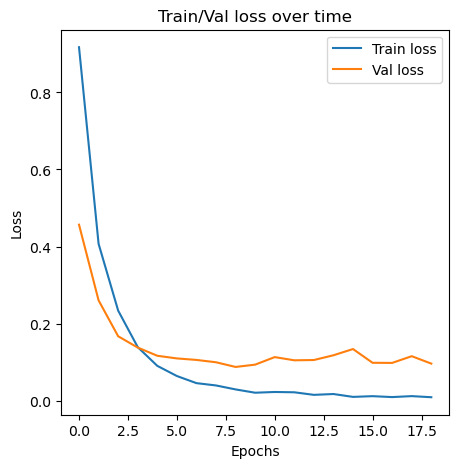

RuntimeError: Error(s) in loading state_dict for EfficientNet:
	Missing key(s) in state_dict: "features.0.0.weight", "features.0.1.weight", "features.0.1.bias", "features.0.1.running_mean", "features.0.1.running_var", "features.1.0.block.0.0.weight", "features.1.0.block.0.1.weight", "features.1.0.block.0.1.bias", "features.1.0.block.0.1.running_mean", "features.1.0.block.0.1.running_var", "features.1.0.block.1.fc1.weight", "features.1.0.block.1.fc1.bias", "features.1.0.block.1.fc2.weight", "features.1.0.block.1.fc2.bias", "features.1.0.block.2.0.weight", "features.1.0.block.2.1.weight", "features.1.0.block.2.1.bias", "features.1.0.block.2.1.running_mean", "features.1.0.block.2.1.running_var", "features.2.0.block.0.0.weight", "features.2.0.block.0.1.weight", "features.2.0.block.0.1.bias", "features.2.0.block.0.1.running_mean", "features.2.0.block.0.1.running_var", "features.2.0.block.1.0.weight", "features.2.0.block.1.1.weight", "features.2.0.block.1.1.bias", "features.2.0.block.1.1.run

In [14]:
# Display loss curve
train_loss_over_time = []
val_loss_over_time = []

with open("loss_over_time.txt", "r") as f:
    for line in f:
        line = line.split()
        train_loss_over_time.append(float(line[0]))
        val_loss_over_time.append(float(line[1]))

plt.figure(figsize=(5, 5))
plt.plot(range(len(train_loss_over_time)), train_loss_over_time, label="Train loss")
plt.plot(range(len(val_loss_over_time)), val_loss_over_time, label="Val loss")
plt.title("Train/Val loss over time")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

# Load best weights into model
model = models.efficientnet_b0(weights=weights, progress=True)
model.classifier = nn.Sequential(nn.Dropout(p=0.6),
                                 nn.Linear(in_features=1280, out_features=4, bias=True))
model.to(DEVICE)
model.load_state_dict(torch.load("best_resnet_weights.pth", weights_only=True))

# MODEL EVALUATION

In [9]:
target_names = ["glioma_tumor", "meningioma_tumor", "no_tumor", "pituitary_tumor"]

def get_report(y_true: np.array, y_preds: np.array) -> pd.DataFrame:
    return pd.DataFrame(classification_report(y_true, y_preds, target_names=target_names, output_dict=True))
                        
def get_predictions(model, dataloader) -> tuple:
    pred_probs = []
    model.eval()
    
    with torch.inference_mode():
        y_true = []
        y_preds = []

        for features, labels in dataloader:
            features = features.to(DEVICE)
            labels = labels.to(DEVICE)
    
            y_train_logits = model(features)
            y_train_probs = torch.softmax(y_train_logits, dim=1)
            pred_probs.append(y_train_probs.cpu())
            y_train_preds = torch.argmax(y_train_probs, dim=1)
            y_preds.append(y_train_preds.cpu())
            y_true.append(labels.cpu())

    pred_probs = torch.concat(pred_probs).numpy()
    y_true = torch.concat(y_true).numpy()
    y_preds = torch.concat(y_preds).numpy()
    
    return (y_true, y_preds, pred_probs)

In [10]:
# PERFORMANCE OF TRAINING SET
y_train_true, y_train_preds, _ = get_predictions(model=model, dataloader=train_dataloader)
train_report = get_report(y_true=y_train_true, y_preds=y_train_preds)
display(train_report)

,glioma_tumor,meningioma_tumor,no_tumor,pituitary_tumor,accuracy,macro avg,weighted avg
precision,1.000000,0.998478,1.0,1.0,0.999562,0.999619,0.999563
recall,0.998457,1.000000,1.0,1.0,0.999562,0.999614,0.999562
f1-score,0.999228,0.999238,1.0,1.0,0.999562,0.999617,0.999562
support,648.000000,656.000000,350.0,630.0,0.999562,2284.000000,2284.000000


In [11]:
# PERFORMANCE OF VALIDATION SET
y_val_true, y_val_preds, _ = get_predictions(model=model, dataloader=val_dataloader)
val_report = get_report(y_true=y_val_true, y_preds=y_val_preds)
display(val_report)

,glioma_tumor,meningioma_tumor,no_tumor,pituitary_tumor,accuracy,macro avg,weighted avg
precision,0.977444,0.951389,0.948718,0.992593,0.969388,0.967536,0.969807
recall,0.935252,0.978571,0.986667,0.985294,0.969388,0.971446,0.969388
f1-score,0.955882,0.964789,0.967320,0.988930,0.969388,0.969230,0.969350
support,139.000000,140.000000,75.000000,136.000000,0.969388,490.000000,490.000000


In [12]:
# PERFORMANCE OF TESTING SET
y_test_true, y_test_preds, y_test_pred_probs = get_predictions(model=model, dataloader=test_dataloader)
test_report = get_report(y_true=y_test_true, y_preds=y_test_preds)
display(test_report)

,glioma_tumor,meningioma_tumor,no_tumor,pituitary_tumor,accuracy,macro avg,weighted avg
precision,0.992063,0.892617,0.924051,0.970588,0.944898,0.944830,0.947121
recall,0.899281,0.943262,0.973333,0.977778,0.944898,0.948414,0.944898
f1-score,0.943396,0.917241,0.948052,0.974170,0.944898,0.945715,0.945061
support,139.000000,141.000000,75.000000,135.000000,0.944898,490.000000,490.000000


In [13]:
def show_confusion_matrix(y_train_true: np.array, y_train_preds: np.array,
                          y_val_true: np.array, y_val_preds: np.array,
                          y_test_true: np.array, y_test_preds: np.array):

    split = ["TRAIN", "VAL", "TEST"]
    ground_truths = [y_train_true, y_val_true, y_test_true]
    predictions = [y_train_preds, y_val_preds, y_test_preds]
    
    fig, ax = plt.subplots(nrows=3, ncols=1, figsize=(15, 25))
    for i in range(3):
        cm = confusion_matrix(ground_truths[i], predictions[i], labels=range(4))
        display = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
        display.plot(ax=ax[i], cmap="Blues")
        display.ax_.set_title(split[i])

    plt.tight_layout()
    plt.show()
    return fig

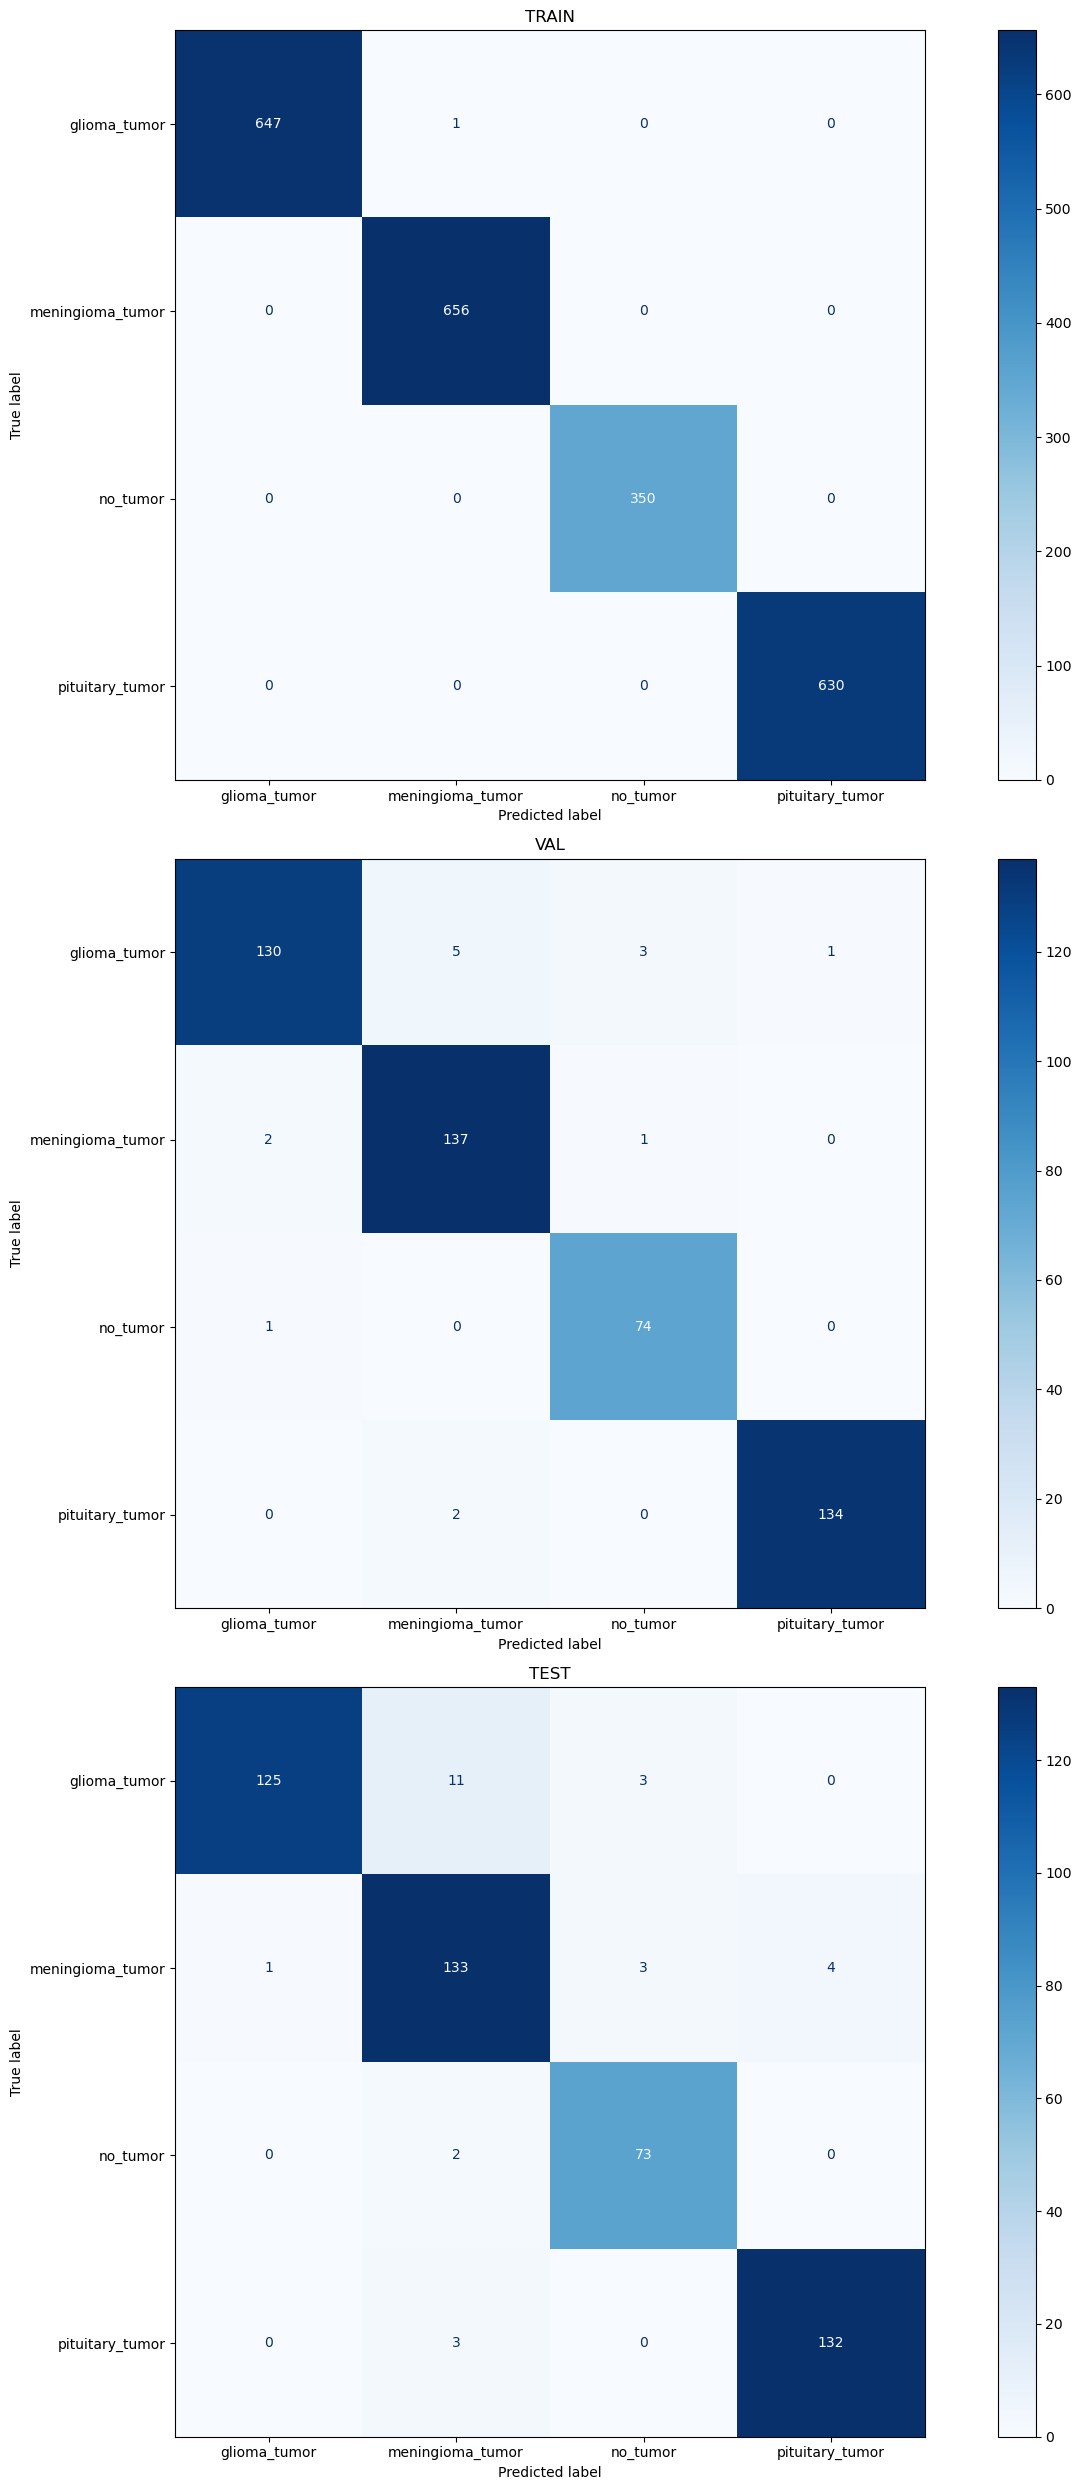

In [14]:
cm = show_confusion_matrix(y_train_true, y_train_preds, y_val_true, y_val_preds, y_test_true, y_test_preds)

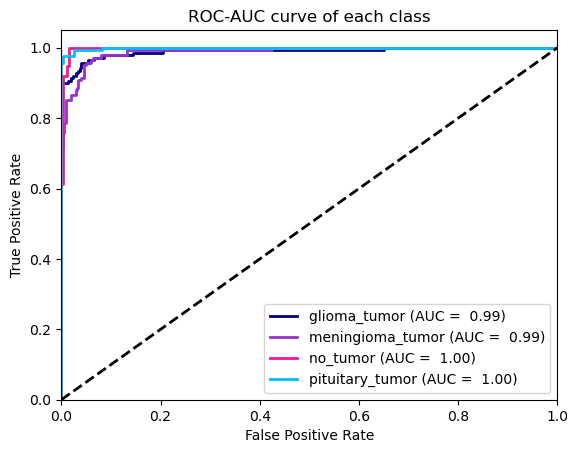

In [15]:
labels = list(range(4))
fpr = dict()
tpr = dict()
roc_auc = dict()

# One vs Rest
for label in labels:
    mask = (y_test_true == label).astype(int)
    fpr[label], tpr[label], _ = roc_curve(y_true=mask, y_score=y_test_pred_probs[:, label])
    roc_auc[label] = auc(fpr[label], tpr[label])

colors = ["navy", "darkorchid", "deeppink", "deepskyblue"]

for label, color in zip(labels, colors):
    plt.plot(fpr[label],
             tpr[label],
             color=color,
             lw=2,
             label=f"{target_names[label]} (AUC = {roc_auc[label]: 0.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC curve of each class")
plt.legend(loc="lower right")
plt.show()